# `numeric_noise`: a smoothing prior for numeric columns

To the model's softmax, digits are categorical symbols: nothing makes $p(4.9 \mid x)$ and
$p(5.0 \mid x)$ close just because the values are. `TrainingConfig.numeric_noise` perturbs every
numeric cell with Gaussian noise as it is serialized, redrawn for every example and epoch, with
$\sigma_c = \texttt{numeric\_noise} \cdot \operatorname{std}(c)$ per column. The model trains on the
neighbourhood of each value and learns a smoother conditional. The DataFrame is never modified,
perturbed values keep the cell's precision, and validation rows are serialized clean.

Below, the Auto MPG regressor fitted twice, identical except for `numeric_noise`, compared under
the scoring decoder, where the shape of the likelihood shows directly.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

from sklm import DiscretizationConfig, GenerationConfig, LanguageModelRegressor, TrainingConfig

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

## Data

Same table as `02-autompg-regressor`.

In [2]:
mpg = sns.load_dataset("mpg").dropna()
features = [
    "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin",
]
X = mpg[features].round(1)
y = mpg["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

## Two fits, one knob apart

In [3]:
def fit_regressor(noise: float) -> LanguageModelRegressor:
    return LanguageModelRegressor(
        backend="mlx",
        model="mlx-community/distilgpt2",
        precision="fp32",
        training=TrainingConfig(epochs=40, batch_size=16, numeric_noise=noise),
        random_state=SEED,
    ).fit(X_train, y_train)


reg_plain = fit_regressor(0.0)
reg_noisy = fit_regressor(0.1)

## Scored predictions

`DiscretizationConfig(bins=0.3, strategy="uniform", estimate="median")` opts `predict` into the
scoring decoder: the observed `mpg` range is cut into equal-width bins (30% as many as there are
distinct values), each represented by its median, and the candidates are ranked by likelihood. The
estimate is the probability-weighted median of that distribution, so a likelihood that scatters
mass on distant values still shows in the prediction.

In [10]:
disc = DiscretizationConfig(bins=0.3, estimate='median', strategy='uniform')
pred_plain = reg_plain.predict(X_test, discretization=disc)
pred_noisy = reg_noisy.predict(X_test, discretization=disc)

for name, pred in [("numeric_noise=0.0", pred_plain), ("numeric_noise=0.1", pred_noisy)]:
    print(
        f"{name}  R2: {r2_score(y_test, pred):6.3f}"
        f"   MAE: {mean_absolute_error(y_test, pred):5.2f}"
        f"   RMSE: {root_mean_squared_error(y_test, pred):5.2f}"
    )

HTML(value='')

HTML(value='')

numeric_noise=0.0  R2:  0.764   MAE:  2.65   RMSE:  3.47
numeric_noise=0.1  R2:  0.836   MAE:  2.23   RMSE:  2.89


## The scored distribution

For three test rows, $p(\texttt{mpg} = v \mid x)$ over every training value; the dashed line is the
true value.

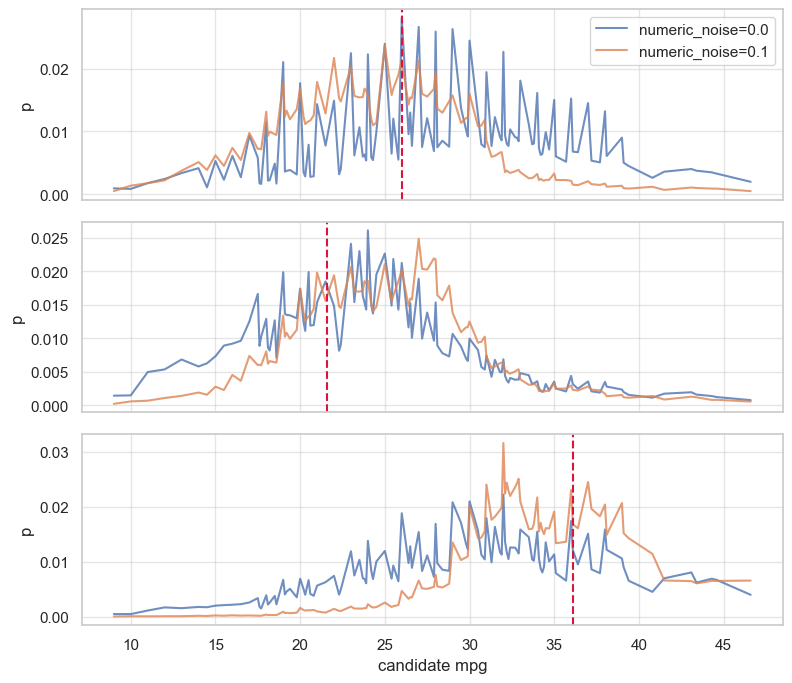

In [11]:
candidates = [float(v) for v in np.unique(reg_plain.target_values_)]
knowns = X_test.iloc[:3].to_dict("records")
gen = GenerationConfig()

proba_plain = reg_plain.lm_.predict_proba_many(knowns, reg_plain.target_col_, candidates, gen)
proba_noisy = reg_noisy.lm_.predict_proba_many(knowns, reg_noisy.target_col_, candidates, gen)

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(candidates, proba_plain[i], label="numeric_noise=0.0", alpha=0.8)
    ax.plot(candidates, proba_noisy[i], label="numeric_noise=0.1", alpha=0.8)
    ax.axvline(float(y_test.iloc[i]), color="crimson", linestyle="--")
    ax.set_ylabel("p")
axes[0].legend()
axes[-1].set_xlabel("candidate mpg")
plt.tight_layout()
plt.show()